In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import rankdata
import itertools
import csv
import ast
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'scatter_{x_axis}_{y_axis}.png')
    plt.show()

def scatterColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis'):
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]
    
    plt.scatter(x_values, y_values, c=z_values, cmap='bwr', edgecolor='k', alpha=0.7)
    plt.plot([0, max(y_values)], [0, max(x_values)], color='black', linestyle='--')
    plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'scatterColor_{x_axis}_{y_axis}_{z_axis}.png')
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglogColor(dict1, dict2, dict3, x_axis = 'x-axis', y_axis = 'y-axis', z_axis = 'z-axis'):
    xgroups = list(dict3.keys())
    x_values = [dict1[xgroup] for xgroup in xgroups]
    y_values = [dict2[xgroup] for xgroup in xgroups]
    z_values = [dict3[xgroup] for xgroup in xgroups]
    
    plt.scatter(np.log10(x_values), np.log10(y_values), c=z_values, cmap='bwr', edgecolor='k', alpha=0.7)
    plt.colorbar(label=z_axis)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig(f'loglogColor_{x_axis}_{y_axis}_{z_axis}.png')
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

In [3]:
x2names = csv2dict('../data/assets/xgroup2/xgroup2names.csv')
x2arc = csv2dict('../data/assets/xgroup2/xgroup2architecture.csv')
xgroup2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
xgroup2ds_ab = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv')

print(len(x2names))
print(len(x2arc))
print(len(xgroup2ns))
print(len(xgroup2ds_ab))

237
2458
397
2230


In [4]:
x2arc

{'1': 'beta barrels',
 '2': 'beta barrels',
 '220': 'beta barrels',
 '236': 'beta barrels',
 '239': 'beta barrels',
 '264': 'beta barrels',
 '270': 'beta barrels',
 '271': 'beta barrels',
 '290': 'beta barrels',
 '3053': 'beta barrels',
 '3083': 'beta barrels',
 '3111': 'beta barrels',
 '3112': 'beta barrels',
 '3158': 'beta barrels',
 '3174': 'beta barrels',
 '3293': 'beta barrels',
 '3335': 'beta barrels',
 '3365': 'beta barrels',
 '3372': 'beta barrels',
 '3375': 'beta barrels',
 '3385': 'beta barrels',
 '3427': 'beta barrels',
 '3445': 'beta barrels',
 '3454': 'beta barrels',
 '3497': 'beta barrels',
 '3504': 'beta barrels',
 '3534': 'beta barrels',
 '3613': 'beta barrels',
 '3665': 'beta barrels',
 '4': 'beta barrels',
 '4011': 'beta barrels',
 '4027': 'beta barrels',
 '4028': 'beta barrels',
 '4056': 'beta barrels',
 '4071': 'beta barrels',
 '4087': 'beta barrels',
 '4113': 'beta barrels',
 '4184': 'beta barrels',
 '4186': 'beta barrels',
 '4200': 'beta barrels',
 '4212': 'beta b

# old classification: a_slash_b = 'a/b barrels' or 'a/b three-layered sandwiches'

In [5]:
a_slash_b = set()
for key, value in x2arc.items():
    if value == 'a/b barrels' or value == 'a/b three-layered sandwiches':
        a_slash_b.add(key) 
len(a_slash_b)

156

## ds (old)

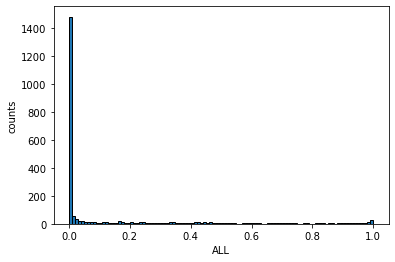

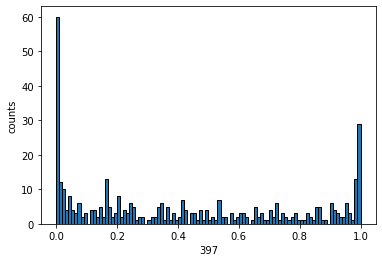

In [6]:
xgroup2ds_ab397 = {}
for key in xgroup2ns.keys():
    xgroup2ds_ab397[key] = xgroup2ds_ab[key]

histogram(xgroup2ds_ab, bins=100, x_axis='ALL')
histogram(xgroup2ds_ab397, bins=100, x_axis='397')

In [7]:
high_ds = set()
mid_ds = set()
low_ds = set()

for key in xgroup2ns.keys():
    if xgroup2ds_ab[key] < 0.1:
        low_ds.add(key)
    elif xgroup2ds_ab[key] > 0.9:
        high_ds.add(key)
    else:
        mid_ds.add(key)
print(len(high_ds))
print(len(mid_ds))
print(len(low_ds))

69
216
112


In [8]:
print(len(a_slash_b & high_ds))    # out of 69
print(len(a_slash_b & mid_ds))    # out of 216
print(len(a_slash_b & low_ds))  # out of 112

16
62
7


In [9]:
# Create the contingency table
contingency_table = np.array([[103, 9], [143, 142]])

# Perform the Chi-squared test
chi2, p, _, _ = chi2_contingency(contingency_table)

# Print the test statistic and p-value
print(f"Chi-squared statistic: {chi2}")
print(f"P-value: {format(p, '.2e')}")

Chi-squared statistic: 57.81484302816919
P-value: 2.88e-14


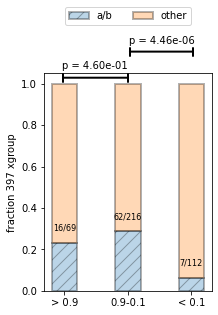

In [10]:
# 397 only
categories = ['> 0.9', '0.9-0.1', '< 0.1']  # high, mid, low
indep_values = [16/69, 62/216, 7/112]
not_indep_values = [53/69, 154/216, 105/112]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, indep_values, label='a/b', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='other', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction 397 xgroup')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square
contingency_table = np.array([[16, 53], [62, 154]])  # '> 0.9' vs. '0.9-0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[62, 154], [7, 105]])  # '0.9-0.1' vs. '< 0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.70, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.5, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

indep_values_str = ['16/69', '62/216', '7/112']
for index in bar_positions:
    plt.text(index, indep_values[index]+0.05, f'{indep_values_str[index]}', ha='center', va='bottom', fontsize=8)

# plt.savefig('AlphaslashBeta_ds_bar397.png', bbox_inches='tight')
plt.show()

In [11]:
# try with ALL 2230 xgroups

high_dsALL = set()
mid_dsALL = set()
low_dsALL = set()

for key in xgroup2ds_ab.keys():
    if xgroup2ds_ab[key] < 0.1:
        low_dsALL.add(key)
    elif xgroup2ds_ab[key] > 0.9:
        high_dsALL.add(key)
    else:
        mid_dsALL.add(key)
        
print(len(high_dsALL))
print(len(mid_dsALL))
print(len(low_dsALL))

88
474
1668


In [12]:
print(len(a_slash_b & high_dsALL))  #out of 88
print(len(a_slash_b & mid_dsALL))  # out of 474
print(len(a_slash_b & low_dsALL))  # out of 1668

21
90
41


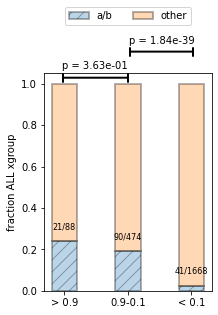

In [13]:
# ALL
categories = ['> 0.9', '0.9-0.1', '< 0.1']  # high, mid, low
indep_values = [21/88, 90/474, 41/1668]
not_indep_values = [67/88, 384/474, 1627/1668]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, indep_values, label='a/b', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='other', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction ALL xgroup')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square
contingency_table = np.array([[21, 67], [90, 384]])  # '> 0.9' vs. '0.9-0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[90, 384], [41, 1627]])  # '0.9-0.1' vs. '< 0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.70, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.5, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

indep_values_str = ['21/88', '90/474', '41/1668']
for index in bar_positions:
    plt.text(index, indep_values[index]+0.05, f'{indep_values_str[index]}', ha='center', va='bottom', fontsize=8)

# plt.savefig('AlphaslashBeta_ds_barALL.png', bbox_inches='tight')
plt.show()

In [14]:
ds10 = set()
ds9 = set()
ds8 = set()
ds7 = set()
ds6 = set()
ds5 = set()
ds4 = set()
ds3 = set()
ds2 = set()
ds1 = set()


for key in xgroup2ns.keys():
    if xgroup2ds_ab[key] < 0.1:
        ds1.add(key)
    elif xgroup2ds_ab[key] < 0.2:
        ds2.add(key)
    elif xgroup2ds_ab[key] < 0.3:
        ds3.add(key)
    elif xgroup2ds_ab[key] < 0.4:
        ds4.add(key)
    elif xgroup2ds_ab[key] < 0.5:
        ds5.add(key)
    elif xgroup2ds_ab[key] < 0.6:
        ds6.add(key)
    elif xgroup2ds_ab[key] < 0.7:
        ds7.add(key)
    elif xgroup2ds_ab[key] < 0.8:
        ds8.add(key)
    elif xgroup2ds_ab[key] < 0.9:
        ds9.add(key)
    elif xgroup2ds_ab[key] <= 1.1:
        ds10.add(key)

In [15]:
print(len(ds10))
print(len(ds9))
print(len(ds8))
print(len(ds7))
print(len(ds6))
print(len(ds5))
print(len(ds4))
print(len(ds3))
print(len(ds2))
print(len(ds1))

69
20
25
21
21
29
27
33
40
112


In [16]:
print(len(a_slash_b & ds10))  
print(len(a_slash_b & ds9))  
print(len(a_slash_b & ds8))  
print(len(a_slash_b & ds7))  
print(len(a_slash_b & ds6))  
print(len(a_slash_b & ds5))  
print(len(a_slash_b & ds4))  
print(len(a_slash_b & ds3))  
print(len(a_slash_b & ds2))  
print(len(a_slash_b & ds1)) 

16
9
11
6
7
7
7
8
7
7


In [17]:
print(len(a_slash_b & ds10) / len(ds10))
print(len(a_slash_b & ds9) / len(ds9))
print(len(a_slash_b & ds8) / len(ds8))
print(len(a_slash_b & ds7) / len(ds7))
print(len(a_slash_b & ds6) / len(ds6))
print(len(a_slash_b & ds5) / len(ds5))
print(len(a_slash_b & ds4) / len(ds4))
print(len(a_slash_b & ds3) / len(ds3))
print(len(a_slash_b & ds2) / len(ds2))
print(len(a_slash_b & ds1) / len(ds1))

0.2318840579710145
0.45
0.44
0.2857142857142857
0.3333333333333333
0.2413793103448276
0.25925925925925924
0.24242424242424243
0.175
0.0625


([<matplotlib.axis.XTick at 0x7fb806fe6370>,
 [Text(0, 0, '≤ 1.0'),
  Text(1, 0, '< 0.9'),
  Text(2, 0, '< 0.8'),
  Text(3, 0, '< 0.7'),
  Text(4, 0, '< 0.6'),
  Text(5, 0, '< 0.5'),
  Text(6, 0, '< 0.4'),
  Text(7, 0, '< 0.3'),
  Text(8, 0, '< 0.2'),
  Text(9, 0, '< 0.1')])

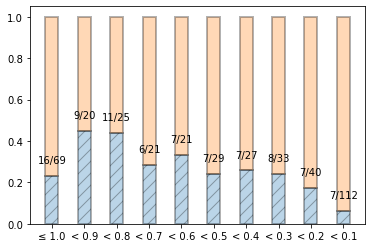

In [18]:
categories = ['≤ 1.0', '< 0.9', '< 0.8', '< 0.7', '< 0.6', '< 0.5', '< 0.4', '< 0.3', '< 0.2', '< 0.1'] 
indep_values = [16/69, 9/20, 11/25, 6/21, 7/21, 7/29, 7/27, 8/33, 7/40, 7/112]
not_indep_values = [53/69, 11/20, 14/25, 15/21, 14/21, 22/29, 20/27, 25/33, 33/40, 105/112]

# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
fig, ax = plt.subplots(figsize=(6, 4))

bars = plt.bar(bar_positions, indep_values, label='a/b', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='other', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

indep_values_str = ['16/69', '9/20', '11/25', '6/21', '7/21', '7/29', '7/27', '8/33', '7/40', '7/112']
for index in bar_positions:
    plt.text(index, indep_values[index]+0.05, f'{indep_values_str[index]}', ha='center', va='bottom', fontsize=10)

plt.xticks(bar_positions, categories)
# plt.savefig('AlphaslashBeta_ds_bar397_10bins.png', bbox_inches='tight')


### closer look at the <= 1.0 high ds folds & their architecture

In [19]:
highDS2arch = {}
for x in ds10:
    highDS2arch[x] = x2arc[x]
len(highDS2arch)

69

In [20]:
highDS2arch

{'284': 'a+b two layers',
 '230': 'a+b two layers',
 '2007': 'a/b three-layered sandwiches',
 '218': 'a+b two layers',
 '2492': 'a+b three layers',
 '321': 'a+b two layers',
 '2498': 'mixed a+b and a/b',
 '205': 'a+b two layers',
 '10': 'beta sandwiches',
 '1': 'beta barrels',
 '7512': 'a/b three-layered sandwiches',
 '212': 'a+b two layers',
 '328': 'a+b two layers',
 '244': 'a+b two layers',
 '141': 'alpha bundles',
 '4': 'beta barrels',
 '206': 'a+b complex topology',
 '7573': 'a/b three-layered sandwiches',
 '283': 'a+b duplicates or obligate multimers',
 '297': 'a+b complex topology',
 '247': 'a+b four layers',
 '208': 'beta duplicates or obligate multimers',
 '2006': 'a/b three-layered sandwiches',
 '192': 'alpha bundles',
 '207': 'beta duplicates or obligate multimers',
 '2002': 'a/b barrels',
 '331': 'a+b two layers',
 '148': 'alpha arrays',
 '2487': 'a/b three-layered sandwiches',
 '7528': 'a/b three-layered sandwiches',
 '3016': 'a+b two layers',
 '103': 'alpha arrays',
 '633

In [21]:
arch2highDS = {}
for key, arch in highDS2arch.items():
    if arch not in arch2highDS.keys():
        arch2highDS[arch] = [key]
    else:
        arch2highDS[arch].append(key)

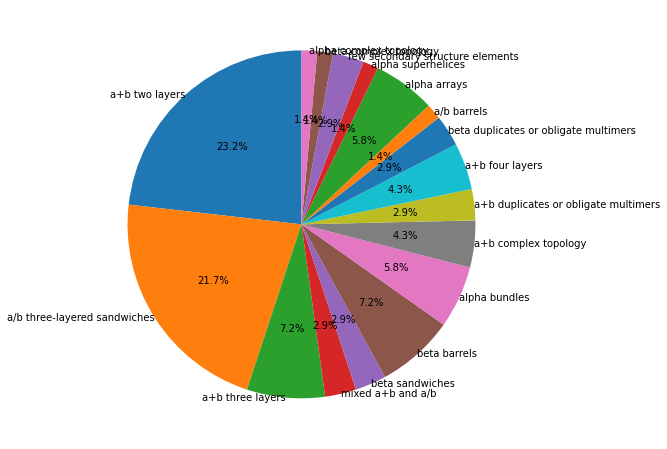

In [22]:
labels = list(arch2highDS.keys())
values = [len(value) for value in arch2highDS.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_highDS.png')
plt.show()

In [23]:
low_ns = {'2002', '2003', '2005', '2007', '206', '218', '325', '4952', '4953', '602'}

In [24]:
xgroup2ds_ab['2002']

1.0000003589638293

In [25]:
for key, values in arch2highDS.items():
    print('----------')
    print(key)
    print('----------')
    for x in values:
        print(x, x2names.get(x, 'No Name'))

----------
a+b two layers
----------
284 FKBP-like
230 T-fold
218 Enolase-N/ribosomal protein
321 Glutamine synthetase-like
205 No Name
212 No Name
328 IF3-like
244 FAD-linked reductases, C-terminal domain-like
331 TBP-like
3016 No Name
309 LuxS, MPP, ThrRS/AlaRS common domain
298 FwdE/GAPDH domain-like
221 beta-Grasp
304 Alpha-beta plaits
306 Glucose permease domain IIB-like
327 Alpha-lytic protease prodomain-like
----------
a/b three-layered sandwiches
----------
2007 Flavodoxin-like
7512 No Name
7573 No Name
2006 HAD domain-like
2487 The "swivelling" beta/beta/alpha domains
7528 No Name
2005 HUP domain-like
2004 P-loop domains-like
7531 No Name
7516 No Name
2011 Phosphorylase/hydrolase-like
2008 Restriction endonuclease-like
2003 Rossmann-like
7574 No Name
7577 No Name
----------
a+b three layers
----------
2492 No Name
301 Bacillus chorismate mutase-like
213 Nat/Ivy
2485 Thioredoxin-like
314 No Name
----------
mixed a+b and a/b
----------
2498 Zincin-like
2484 Ribonuclease H-like
-

## ns (old)

In [27]:
# look at network size < 3600 vs. ≥ 3600
group1 = {}
group2 = {}
for xgroup in xgroup2ns:
    if xgroup2ns[xgroup] < 3600:
        group1[xgroup] = xgroup2ns[xgroup]
    else:
        group2[xgroup] = xgroup2ns[xgroup]

In [30]:
print(len(a_slash_b & low_ns))
print(len(a_slash_b & set(group1)))
print(len(a_slash_b & set(xgroup2ds_ab397.keys())))

4
13
85


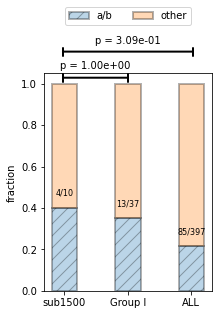

In [31]:
# Data
categories = ['sub1500', 'Group I', 'ALL']
indep_values = [4/10, 13/37, 85/397]
not_indep_values = [6/10, 24/37, 312/397]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, indep_values, label='a/b', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='other', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square
contingency_table = np.array([[4, 6], [13, 24]])  # 'sub1500' vs. 'Group I'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[4, 6], [85, 312]])  # 'sub1500' vs. 'ALL'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.50, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# annotate fractions
indep_values_str = ['4/10', '13/37', '85/397']
for index in bar_positions:
    plt.text(index, indep_values[index]+0.05, f'{indep_values_str[index]}', ha='center', va='bottom', fontsize=8)

# plt.savefig('AlphaslashBeta_ns_bar397.png', bbox_inches='tight')
plt.show()

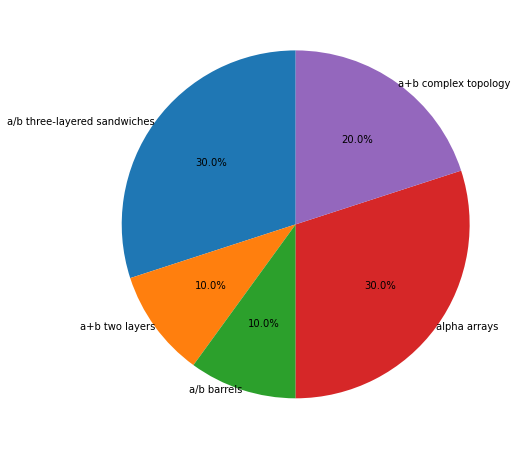

In [32]:
# low_ns (sub1500)

low_ns2arch = {}
for x in low_ns:
    low_ns2arch[x] = x2arc[x]

arch2low_ns = {}
for key, arch in low_ns2arch.items():
    if arch not in arch2low_ns.keys():
        arch2low_ns[arch] = [key]
    else:
        arch2low_ns[arch].append(key)

labels = list(arch2low_ns.keys())
values = [len(value) for value in arch2low_ns.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_low_ns.png')
plt.show()

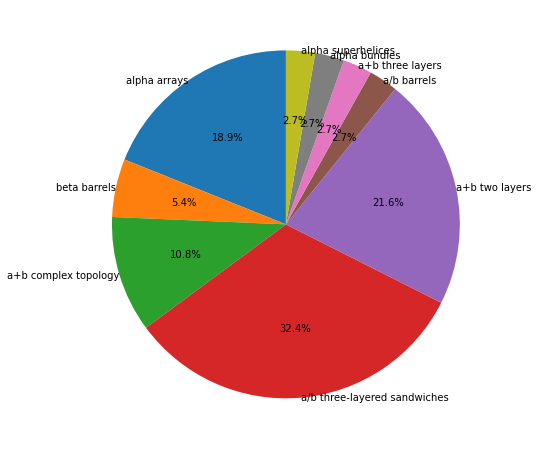

In [33]:
# group1 (sub3600)

group12arch = {}
for x in group1:
    group12arch[x] = x2arc[x]

arch2group1 = {}
for key, arch in group12arch.items():
    if arch not in arch2group1.keys():
        arch2group1[arch] = [key]
    else:
        arch2group1[arch].append(key)

labels = list(arch2group1.keys())
values = [len(value) for value in arch2group1.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_group1.png')
plt.show()

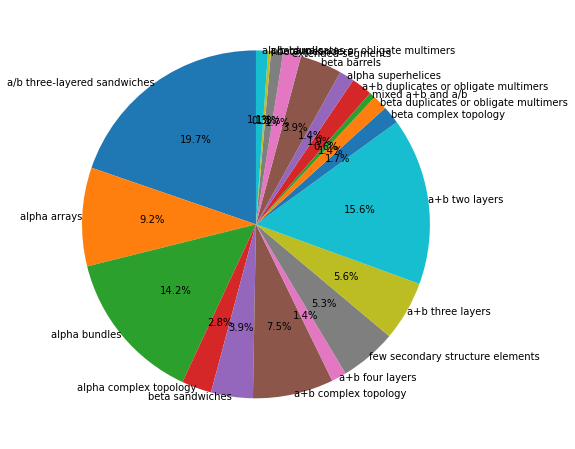

In [34]:
# group2

group22arch = {}
for x in group2:
    group22arch[x] = x2arc[x]

arch2group2 = {}
for key, arch in group22arch.items():
    if arch not in arch2group2.keys():
        arch2group2[arch] = [key]
    else:
        arch2group2[arch].append(key)

labels = list(arch2group2.keys())
values = [len(value) for value in arch2group2.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_group2.png')
plt.show()

# new classification:

In [35]:
new = {'beta': ['beta barrels',
 'beta meanders',
 'beta sandwiches',
 'beta duplicates or obligate multimers',
 'beta complex topology'], 'alpha': ['alpha arrays',
 'alpha bundles',
 'alpha duplicates or obligate multimers',
 'alpha superhelices',
 'alpha complex topology'], 'mixed': ['a+b two layers',
 'a+b three layers',
 'a+b four layers',
 'a+b complex topology',
 'a+b duplicates or obligate multimers',
 'a/b barrels',
 'a/b three-layered sandwiches',
 'mixed a+b and a/b'], 'other': ['few secondary structure elements',
 'extended segments']}

In [36]:
new.keys()

dict_keys(['beta', 'alpha', 'mixed', 'other'])

In [37]:
new['alpha']

['alpha arrays',
 'alpha bundles',
 'alpha duplicates or obligate multimers',
 'alpha superhelices',
 'alpha complex topology']

In [38]:
alpha = set()
beta = set()
mixed = set()
other = set()

for key, value in x2arc.items():
    if value in new['alpha']:
        alpha.add(key)
    if value in new['beta']:
        beta.add(key) 
    if value in new['mixed']:
        mixed.add(key) 
    if value in new['other']:
        other.add(key) 

print(len(alpha))
print(len(beta))
print(len(mixed))
print(len(other))
print(len(alpha) + len(beta) + len(mixed) + len(other))
print(len(x2arc.keys()))

921
276
847
414
2458
2458


In [39]:
# 2458 > 2230 because some xgroups were lost
# from being only associated with domains with 1) ambiguous FtoX mapping and/or 2) fgroup,fgroup with x1 ≠ x2

# 2230 > 2036 when you look at folds with ds>0 in Arc, Bac, or Euk reference genomes

In [40]:
alpha397 = set()
beta397 = set()
mixed397 = set()
other397 = set()

for x in xgroup2ns:  # 397
    if x in alpha:
        alpha397.add(x)
    if x in beta:
        beta397.add(x)
    if x in mixed:
        mixed397.add(x)
    if x in other:
        other397.add(x)

print(len(alpha397))
print(len(beta397))
print(len(mixed397))
print(len(other397))
print(len(alpha397) + len(beta397) + len(mixed397) + len(other397))

112
45
215
25
397


## ds (new)

In [41]:
print(len(mixed397 & high_ds))    # out of 69
print(len(mixed397 & mid_ds))    # out of 216
print(len(mixed397 & low_ds))     # out of 112

47
132
36


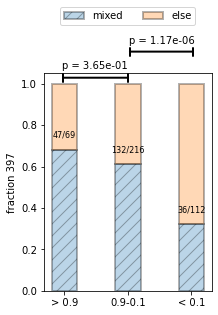

In [42]:
# 397 only
categories = ['> 0.9', '0.9-0.1', '< 0.1']  # high, mid, low
mixed_values = [47/69, 132/216, 36/112]
else_values = [22/69, 84/216, 76/112]

# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, mixed_values, label='mixed', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, else_values, bottom=mixed_values, label='else', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction 397')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square
contingency_table = np.array([[47, 22], [132, 84]])  # '> 0.9' vs. '0.9-0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[132, 84], [36, 76]])  # '0.9-0.1' vs. '< 0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.70, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.5, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# annotate fractions
mixed_values_str = ['47/69', '132/216', '36/112']
for index in bar_positions:
    plt.text(index, mixed_values[index]+0.05, f'{mixed_values_str[index]}', ha='center', va='bottom', fontsize=8)

# plt.savefig('AlphaslashBeta_ds_bar397_new.png', bbox_inches='tight')
plt.show()


In [43]:
print(len(mixed & high_dsALL))  #out of 88
print(len(mixed & mid_dsALL))  # out of 474
print(len(mixed & low_dsALL))  # out of 1668

61
245
479


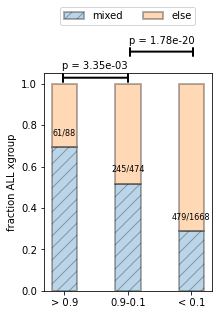

In [44]:
# ALL
categories = ['> 0.9', '0.9-0.1', '< 0.1']  # high, mid, low
indep_values = [61/88, 245/474, 479/1668]
not_indep_values = [27/88, 229/474, 1189/1668]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, indep_values, label='mixed', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='else', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction ALL xgroup')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square
contingency_table = np.array([[61, 27], [245, 229]])  # '> 0.9' vs. '0.9-0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[245, 229], [479, 1189]])  # '0.9-0.1' vs. '< 0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.70, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.5, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

indep_values_str = ['61/88', '245/474', '479/1668']
for index in bar_positions:
    plt.text(index, indep_values[index]+0.05, f'{indep_values_str[index]}', ha='center', va='bottom', fontsize=8)

# plt.savefig('AlphaslashBeta_ds_barALL_new.png', bbox_inches='tight')
plt.show()

In [45]:
print(len(ds10)) 
print(len(ds9))  
print(len(ds8))  
print(len(ds7))  
print(len(ds6))  
print(len(ds5))  
print(len(ds4))  
print(len(ds3))  
print(len(ds2))  
print(len(ds1))  

69
20
25
21
21
29
27
33
40
112


In [46]:
print(len(mixed397 & ds10)) 
print(len(mixed397 & ds9)) 
print(len(mixed397 & ds8)) 
print(len(mixed397 & ds7)) 
print(len(mixed397 & ds6)) 
print(len(mixed397 & ds5)) 
print(len(mixed397 & ds4)) 
print(len(mixed397 & ds3)) 
print(len(mixed397 & ds2)) 
print(len(mixed397 & ds1)) 

47
12
15
15
18
19
15
16
22
36


([<matplotlib.axis.XTick at 0x7fb808325250>,
 [Text(0, 0, '≤ 1.0'),
  Text(1, 0, '< 0.9'),
  Text(2, 0, '< 0.8'),
  Text(3, 0, '< 0.7'),
  Text(4, 0, '< 0.6'),
  Text(5, 0, '< 0.5'),
  Text(6, 0, '< 0.4'),
  Text(7, 0, '< 0.3'),
  Text(8, 0, '< 0.2'),
  Text(9, 0, '< 0.1')])

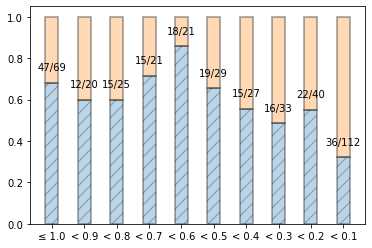

In [47]:
categories = ['≤ 1.0', '< 0.9', '< 0.8', '< 0.7', '< 0.6', '< 0.5', '< 0.4', '< 0.3', '< 0.2', '< 0.1'] 
indep_values = [47/69, 12/20, 15/25, 15/21, 18/21, 19/29, 15/27, 16/33, 22/40, 36/112]
not_indep_values = [22/69, 8/20, 10/25, 6/21, 3/21, 10/29, 12/27, 17/33, 18/40, 76/112]

# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
fig, ax = plt.subplots(figsize=(6, 4))

bars = plt.bar(bar_positions, indep_values, label='mixed', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, not_indep_values, bottom=indep_values, label='else', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

indep_values_str = ['47/69', '12/20', '15/25', '15/21', '18/21', '19/29', '15/27', '16/33', '22/40', '36/112']
for index in bar_positions:
    plt.text(index, indep_values[index]+0.05, f'{indep_values_str[index]}', ha='center', va='bottom', fontsize=10)

plt.xticks(bar_positions, categories)
# plt.savefig('AlphaslashBeta_ds_bar397_10bins_new.png', bbox_inches='tight')


In [48]:
arch2highDSnew = {'beta': [], 'alpha': [], 'mixed': [], 'other': []}
for arch, x_list in arch2highDS.items():
    if arch in new['alpha']:
        arch2highDSnew['alpha'].extend(arch2highDS[arch])
    if arch in new['beta']:
        arch2highDSnew['beta'].extend(arch2highDS[arch])
    if arch in new['mixed']:
        arch2highDSnew['mixed'].extend(arch2highDS[arch])
    if arch in new['other']:
        arch2highDSnew['other'].extend(arch2highDS[arch])

In [49]:
arch2highDSnew['alpha']

['141', '192', '633', '632', '148', '103', '101', '102', '109', '131']

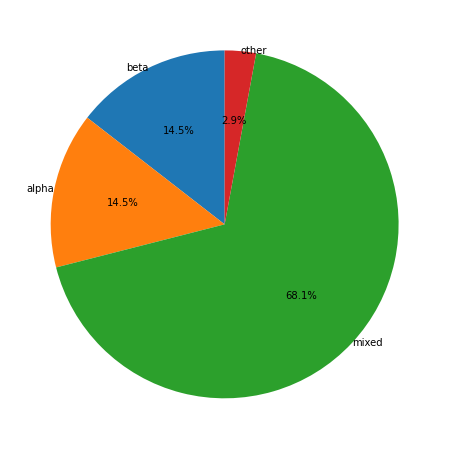

In [50]:
labels = list(arch2highDSnew.keys())
values = [len(value) for value in arch2highDSnew.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_highDS_new.png')
plt.show()

## ns (new)

In [51]:
low_ns & mixed397

{'2002', '2003', '2005', '2007', '206', '218', '325'}

In [53]:
len(set(group1) & mixed397)

26

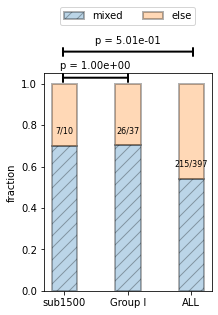

In [55]:
# Data
categories = ['sub1500', 'Group I', 'ALL']
mixed_values = [7/10, 26/37, 215/397]
else_values = [3/10, 11/37, 182/397]


# Create a stacked bar chart
bar_width = 0.4
bar_positions = [0, 1, 2]
fig, ax = plt.subplots(figsize=(3, 4))

plt.bar(bar_positions, mixed_values, label='mixed', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3, hatch='//',  width=bar_width)
plt.bar(bar_positions, else_values, bottom=mixed_values, label='else', linewidth=2, edgecolor=(0, 0, 0, 1), alpha = 0.3,  width=bar_width)

# Set labels
plt.xticks(bar_positions, categories)
plt.ylabel('fraction')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2)

# chi-square
contingency_table = np.array([[7, 3], [26, 11]])  # 'sub1500' vs. 'Group I'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.035), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[7, 3], [215, 182]])  # 'sub1500' vs. 'ALL'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.50, 1.15), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 0.98), xytext=(0.51, 0.98), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.1), xytext=(0.9, 1.1), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# annotate fractions
mixed_values_str = ['7/10', '26/37', '215/397']
for index in bar_positions:
    plt.text(index, mixed_values[index]+0.05, f'{mixed_values_str[index]}', ha='center', va='bottom', fontsize=8)

# plt.savefig('AlphaslashBeta_ns_bar397_new.png', bbox_inches='tight')
plt.show()


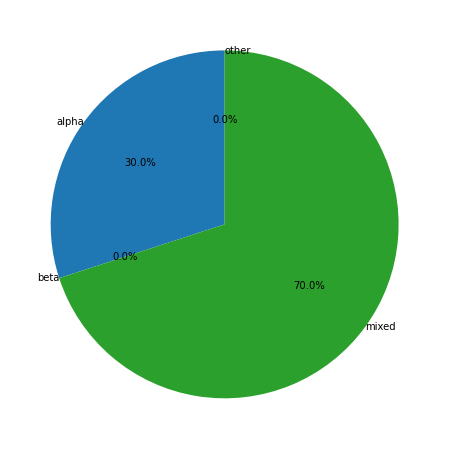

In [56]:
# low_ns

arch2low_nsnew = {'alpha': [], 'beta': [], 'mixed': [], 'other': []}
for x in low_ns:
    if x in alpha397:
        arch2low_nsnew['alpha'].append(x)
    if x in beta397:
        arch2low_nsnew['beta'].append(x)
    if x in mixed397:
        arch2low_nsnew['mixed'].append(x)
    if x in other397:
        arch2low_nsnew['other'].append(x)

labels = list(arch2low_nsnew.keys())
values = [len(value) for value in arch2low_nsnew.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_low_ns_new.png')
plt.show()

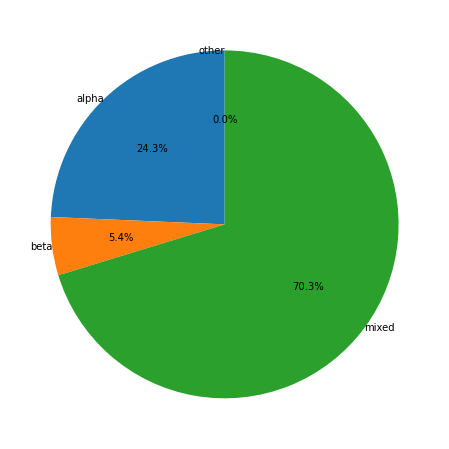

In [57]:
# group1 (sub3600)

arch2group1new = {'alpha': [], 'beta': [], 'mixed': [], 'other': []}
for x in group1:
    if x in alpha397:
        arch2group1new['alpha'].append(x)
    if x in beta397:
        arch2group1new['beta'].append(x)
    if x in mixed397:
        arch2group1new['mixed'].append(x)
    if x in other397:
        arch2group1new['other'].append(x)

labels = list(arch2group1new.keys())
values = [len(value) for value in arch2group1new.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_group1_new.png')
plt.show()

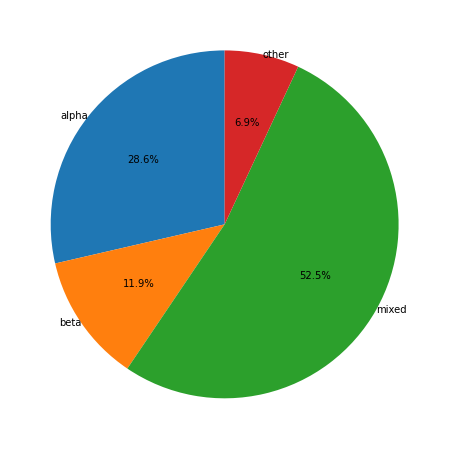

In [60]:
# group2 (sup3600)

arch2group2new = {'alpha': [], 'beta': [], 'mixed': [], 'other': []}
for x in group2:
    if x in alpha397:
        arch2group2new['alpha'].append(x)
    if x in beta397:
        arch2group2new['beta'].append(x)
    if x in mixed397:
        arch2group2new['mixed'].append(x)
    if x in other397:
        arch2group2new['other'].append(x)

labels = list(arch2group2new.keys())
values = [len(value) for value in arch2group2new.values()]

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, labeldistance=1)
# plt.savefig('pie_arch_group2_new.png')
plt.show()

# let's simplify it
ns: 2230, 397, group I

ds: > 0.9, 09-0.1, <0.1

fo: early, mid, late (360/3)?

In [ ]:
# ns: 2230, 397, group I

In [61]:
keys_to_remove = []
for key in x2arc.keys():
    if key not in xgroup2ds_ab.keys():
        keys_to_remove.append(key)

for key in keys_to_remove:
    x2arc.pop(key)

In [62]:
# ALL but make sure it's 2230, not 2458
alpha = set()
beta = set()
mixed = set()
other = set()

for key, value in x2arc.items():
    if value in new['alpha']:
        alpha.add(key)
    if value in new['beta']:
        beta.add(key) 
    if value in new['mixed']:
        mixed.add(key) 
    if value in new['other']:
        other.add(key) 

In [63]:
print(len(alpha), len(beta), len(mixed), len(other))
print(len(alpha) + len(beta) + len(mixed) + len(other))

809 252 785 384
2230


In [64]:
print(len(alpha397), len(beta397), len(mixed397), len(other397))
print(len(alpha397) + len(beta397) + len(mixed397) + len(other397))

112 45 215 25
397


In [66]:
print(len(set(group1) & alpha397), len(set(group1) & beta397), len(set(group1) & mixed397), len(set(group1) & other397))

9 2 26 0


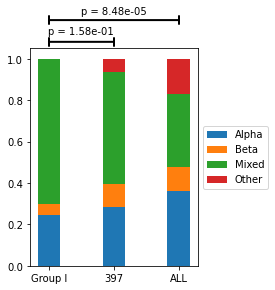

In [67]:
categories = ['Group I', '397', 'ALL']
alpha_values = [9/37, 112/397, 809/2230]
beta_values = [2/37, 45/397, 252/2230]
mixed_values = [26/37, 215/397, 785/2230]
other_values = [0/37, 25/397, 384/2230]

x = np.arange(len(categories))  # the label locations
width = 0.35  # the width of the bars
bar_positions = [0, 1, 2]

fig, ax = plt.subplots(figsize=(3, 4))

# Plotting bars
ax.bar(x, alpha_values, width, label='Alpha')
ax.bar(x, beta_values, width, bottom=alpha_values, label='Beta')
ax.bar(x, mixed_values, width, bottom=np.array(alpha_values) + np.array(beta_values), label='Mixed')
ax.bar(x, other_values, width, bottom=np.array(alpha_values) + np.array(beta_values) + np.array(mixed_values), label='Other')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# chi-square
contingency_table = np.array([[9, 2, 26, 0], [112, 45, 215, 25]])  # 'Group I' vs. '397'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[9, 2, 26, 0], [809, 252, 785, 384]])  # 'Group I' vs. 'ALL' 
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.50, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.13), xytext=(0.9, 1.13), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# plt.savefig('Mixed_ns_bar.png', bbox_inches='tight')
plt.show()

In [ ]:
# ds: > 0.9, 09-0.1, <0.1

In [68]:
print(len(alpha397 & high_ds), len(alpha397 & mid_ds), len(alpha397 & low_ds))  # out of 69, 216, 112
print(len(beta397 & high_ds), len(beta397 & mid_ds), len(beta397 & low_ds))  # out of 69, 216, 112
print(len(mixed397 & high_ds), len(mixed397 & mid_ds), len(mixed397 & low_ds))  # out of 69, 216, 112
print(len(other397 & high_ds), len(other397 & mid_ds), len(other397 & low_ds))  # out of 69, 216, 112

10 49 53
10 22 13
47 132 36
2 13 10


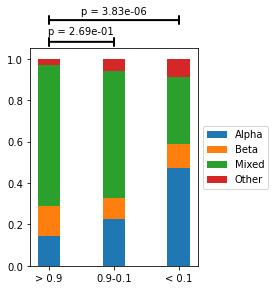

In [69]:
# ds (397)
categories = ['> 0.9', '0.9-0.1', '< 0.1']  # high, mid, low
alpha_valuesDS = [10/69, 49/216, 53/112]
beta_valuesDS = [10/69, 22/216, 13/112]
mixed_valuesDS = [47/69, 132/216, 36/112]
other_valuesDS = [2/69, 13/216, 10/112]

x = np.arange(len(categories))  # the label locations
width = 0.35  # the width of the bars
bar_positions = [0, 1, 2]

fig, ax = plt.subplots(figsize=(3, 4))

# Plotting bars
ax.bar(x, alpha_valuesDS, width, label='Alpha')
ax.bar(x, beta_valuesDS, width, bottom=alpha_valuesDS, label='Beta')
ax.bar(x, mixed_valuesDS, width, bottom=np.array(alpha_valuesDS) + np.array(beta_valuesDS), label='Mixed')
ax.bar(x, other_valuesDS, width, bottom=np.array(alpha_valuesDS) + np.array(beta_valuesDS) + np.array(mixed_valuesDS), label='Other')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# chi-square
contingency_table = np.array([[10, 10, 47, 2], [49, 22, 132, 13]])  # '> 0.9', '0.9-0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[10, 10, 47, 2], [53, 13, 36, 10]])  # '> 0.9', '< 0.1'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.50, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.13), xytext=(0.9, 1.13), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# plt.savefig('Mixed_ds_bar.png', bbox_inches='tight')
plt.show()

In [ ]:
# fo: early, mid, late (360/3)?

In [70]:
x2foNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')
x2foALL = csv2dict('../data/assets/xgroup2/xgroup2foAveALL.csv')

In [71]:
x2foNONE

{'2002': 2.0,
 '1': 3.0,
 '2487': 4.0,
 '2006': 5.0,
 '2003': 6.511,
 '246': 6.489,
 '7542': 16.753,
 '62': 24.174,
 '7525': 11.31,
 '218': 11.444,
 '2007': 12.444,
 '304': 11.109,
 '12': 14.482,
 '11': 15.482,
 '109': 16.719,
 '10': 17.245,
 '210': 13.523,
 '7515': 18.972,
 '279': 19.972,
 '7577': 20.972,
 '3016': 21.972,
 '281': 22.972,
 '7528': 24.22,
 '331': 25.22,
 '2011': 27.438,
 '301': 27.495,
 '7572': 27.438,
 '206': 30.341,
 '325': 30.293,
 '282': 31.364,
 '7527': 32.662,
 '805': 32.625,
 '7529': 37.745,
 '180': 37.757,
 '3691': 37.747,
 '4126': 24.457,
 '7512': 37.772,
 '7518': 23.468,
 '7560': 37.672,
 '7579': 37.741,
 '4002': 45.281,
 '297': 45.312,
 '286': 45.495,
 '2004': 47.96,
 '7580': 48.052,
 '70': 45.435,
 '205': 45.412,
 '7554': 45.606,
 '315': 45.447,
 '2': 57.497,
 '5104': 57.33,
 '7567': 57.502,
 '247': 57.67,
 '307': 57.468,
 '7561': 57.338,
 '212': 57.594,
 '7517': 61.548,
 '5': 57.437,
 '7510': 57.405,
 '7571': 57.484,
 '7574': 57.657,
 '208': 57.19,
 '7516':

In [72]:
ranked_items = sorted(x2foNONE.items(), key=lambda x: x[1])

early = set()
mid = set()
late = set()

counter = 0
for x, value in ranked_items:
    if counter < 132:
        early.add(x)
        counter += 1
    elif counter > 264:
        late.add(x)
        counter += 1
    else:
        mid.add(x)
        counter += 1

In [73]:
print(len(early), len(mid), len(late))
print(len(early) + len(mid) + len(late))

132 133 132
397


In [74]:
print(len(alpha397 & early), len(alpha397 & mid), len(alpha397 & late))  # out of 132 133 132
print(len(beta397 & early), len(beta397 & mid), len(beta397 & late))  # out of 132 133 132
print(len(mixed397 & early), len(mixed397 & mid), len(mixed397 & late))  # out of 132 133 132
print(len(other397 & early), len(other397 & mid), len(other397 & late))  # out of 132 133 132

21 43 48
18 8 19
90 75 50
3 7 15


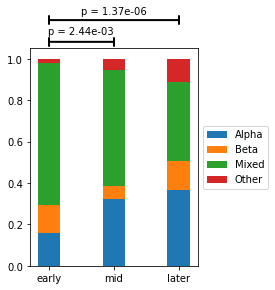

In [75]:
# fo (397)
categories = ['early', 'mid', 'later']  # 132, 133, 132
alpha_valuesFO = [21/132, 43/133, 48/132]
beta_valuesFO = [18/132, 8/133, 19/132]
mixed_valuesFO = [90/132, 75/133, 50/132]
other_valuesFO = [3/132, 7/133, 15/132]

x = np.arange(len(categories))  # the label locations
width = 0.35  # the width of the bars
bar_positions = [0, 1, 2]

fig, ax = plt.subplots(figsize=(3, 4))

# Plotting bars
ax.bar(x, alpha_valuesFO, width, label='Alpha')
ax.bar(x, beta_valuesFO, width, bottom=alpha_valuesFO, label='Beta')
ax.bar(x, mixed_valuesFO, width, bottom=np.array(alpha_valuesFO) + np.array(beta_valuesFO), label='Mixed')
ax.bar(x, other_valuesFO, width, bottom=np.array(alpha_valuesFO) + np.array(beta_valuesFO) + np.array(mixed_valuesFO), label='Other')

ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# chi-square
contingency_table = np.array([[21, 18, 90, 3], [43, 8, 75, 7]])  # 'early', 'mid'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.305, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

contingency_table = np.array([[21, 18, 90, 3], [48, 19, 50, 15]])  # 'early', 'later'
chi2, p, _, _ = chi2_contingency(contingency_table)
ax.annotate(f'p = {format(p, ".2e")}', xy=(0.50, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.1, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.1, 1.13), xytext=(0.9, 1.13), xycoords='axes fraction',
            textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))

# plt.savefig('Mixed_fo_bar.png', bbox_inches='tight')
plt.show()